# Estudo de caso - Dispositivos inteligentes para saúde


## Resumo

Analisar dados de condicionamento físico de dispositivos inteligentes para obter informações sobre como os consumidores estão usando esses dispositivos. Seguem algumas perguntas para nortear a análise:

1. Quais são algumas das tendências no uso dos dispositivos inteligentes para monitoramento de condicionamento físico
2. Como essas tendências podem ser aplicadas para melhorar a interação dos usuários desses dispositivos
3. Qual seria a estratégia de marketing utilizada, de acordo com os insights encontrados

## Preparação

Serão utilizados dados públicos que exploram hábitos diários de rastreadores de condicionamento físico FitBit. Segue link para o conjunto de dados: <https://www.kaggle.com/datasets/arashnic/fitbit>.

De acordo com a descrição do conjunto de dados, ele foi gerado por usuários do FitBit que foram entrevistados, através de uma pesquisa via Amazon Mechanical Turk, entre os dias 12/03/2016 e 12/05/2016. Esses usuários consentiram com o uso das informações coletadas pelos dispositivos.

Após o download do conjunto de dados (25 MB), os arquivos CSV foram salvos em uma pasta "database", subpasta "original".

Em geral, alguns pontos podem ser observados:
1. Foram apenas 33 entrevistados, representando uma amostra muito baixa da população. Portanto, essa amostra pode conter viés.
2. Os dados são de 2016, portanto desatualizados. Nesse intervalo de tempo, provavelmente, a tecnologia dos dispostivos inteligentes está mais avançada.

In [1]:
# Importanção das bibliotecas utilizadas no projeto

# Pandas: biblioteca de analise de dados e ferramentas de manipulação de conjunto de dados
import pandas as pd

# OS: biblioteca utilizada para interação entre Python e Sistema Operacional
import os

# Seaborn e matplotlib: bibliotecas de visualização de dados  
import seaborn as sns
import matplotlib.pyplot as plt

# Numpy: biblioteca de vetores n-dimensionais
import numpy as np

### Arquivos baixados
Percebe-se no código seguinte, que os arquivos possuem um padrão de nomenclatura. Nesse padrão, pode-se perceber 3 grandes grupos:

1. **Daily**: informações diárias, onde cada linha representa um dia.
2. **Hourly**: informações de hora em hora, onde cada linha representa uma hora do dia.
3. **Minute**: Informações minuto a minuto. Nesse grupo, existem dois tipos de arquivos, com mesmas informações, porém organizados de forma diferente. 
    * Narrow: dados do tipo longo (ou estreito), onde cada linha representa uma entrada de informação. Possui mais linhas e menos colunas.
    * Wide: dados do tipo largo. Nesse caso, cada coluna representa uma entrada de informação. Possui mais colunas e menos linhas.

In [12]:
# Listando os arquivos baixados
path = r'C:\Users\luisf\Desktop\database\original'
directory = os.listdir(path)

directory

['dailyActivity_merged.csv',
 'dailyCalories_merged.csv',
 'dailyIntensities_merged.csv',
 'dailySteps_merged.csv',
 'heartrate_seconds_merged.csv',
 'hourlyCalories_merged.csv',
 'hourlyIntensities_merged.csv',
 'hourlySteps_merged.csv',
 'minuteCaloriesNarrow_merged.csv',
 'minuteCaloriesWide_merged.csv',
 'minuteIntensitiesNarrow_merged.csv',
 'minuteIntensitiesWide_merged.csv',
 'minuteMETsNarrow_merged.csv',
 'minuteSleep_merged.csv',
 'minuteStepsNarrow_merged.csv',
 'minuteStepsWide_merged.csv',
 'sleepDay_merged.csv',
 'weightLogInfo_merged.csv']

## Observando os dados
Nesse momento, os dados foram exportados ao Bigquery (SQL), com o objetivo de explorá-los, assim, tendo mais conhecimento das informações. Alguns pontos podem ser observados:

* Todos os arquivos possuem uma coluna de Id (representando o usuário) e uma coluna de data ou data/hora, com nomes variados, dependendo do conjunto de dados.
* Os tipos das colunas estão corretos, com exceção das colunas de data, que apresentam o tipo string (no Python, Object)
* O arquivo dailyActivity é a junção das informações dos arquivos dailyCalories, Intensities e Steps.
* Utilizando a mesma idéia do item acima, pode-se juntar os arquivos do grupo hourly e minute, assim tendo um conjunto de dados único, para cada grupo.

In [13]:
"""
Encontrando o número de linhas de cada conjunto de dados:

Aqui, percebemos que cada conjunto de dados dos grandes grupos (daily, hourly, minuteNarrow e minuteWide) apresentam quantidade
de linhas iguais. Portanto, os conjuntos de dados se completam e podem ser mesclados.
"""

for file in directory:
    file_path = os.path.join(path, file)
    df = pd.read_csv(file_path)
    print(file, df.shape[0])

dailyActivity_merged.csv 940
dailyCalories_merged.csv 940
dailyIntensities_merged.csv 940
dailySteps_merged.csv 940
heartrate_seconds_merged.csv 2483658
hourlyCalories_merged.csv 22099
hourlyIntensities_merged.csv 22099
hourlySteps_merged.csv 22099
minuteCaloriesNarrow_merged.csv 1325580
minuteCaloriesWide_merged.csv 21645
minuteIntensitiesNarrow_merged.csv 1325580
minuteIntensitiesWide_merged.csv 21645
minuteMETsNarrow_merged.csv 1325580
minuteSleep_merged.csv 188521
minuteStepsNarrow_merged.csv 1325580
minuteStepsWide_merged.csv 21645
sleepDay_merged.csv 413
weightLogInfo_merged.csv 67


In [15]:
"""
Utilizarei a função info para observar o tipo dos dados e se existem valores nulos, para cada conjunto. Nota-se que, apenas
para o conjunto de dados "weightLogInfo", coluna Fat, existem valores nulos. Inclusive, apenas 2 valores não nulos.
Devido a falta de informação, essa coluna não será utilizada nas análises.

Notamos, por exemplo, que os arquivos hourlyCalories_merged.csv, hourlyIntensities_merged.csv e hourlySteps_merged.csv 
podem ser mesclados, gerando um arquivo único, com as informações de calorias, intensidade e passos, por hora.
"""

for file in directory:
    file_path = os.path.join(path, file)
    df = pd.read_csv(file_path)
    print(file)
    print(df.info())
    print('\n')

dailyActivity_merged.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null  

minuteIntensitiesWide_merged.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21645 entries, 0 to 21644
Data columns (total 62 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            21645 non-null  int64 
 1   ActivityHour  21645 non-null  object
 2   Intensity00   21645 non-null  int64 
 3   Intensity01   21645 non-null  int64 
 4   Intensity02   21645 non-null  int64 
 5   Intensity03   21645 non-null  int64 
 6   Intensity04   21645 non-null  int64 
 7   Intensity05   21645 non-null  int64 
 8   Intensity06   21645 non-null  int64 
 9   Intensity07   21645 non-null  int64 
 10  Intensity08   21645 non-null  int64 
 11  Intensity09   21645 non-null  int64 
 12  Intensity10   21645 non-null  int64 
 13  Intensity11   21645 non-null  int64 
 14  Intensity12   21645 non-null  int64 
 15  Intensity13   21645 non-null  int64 
 16  Intensity14   21645 non-null  int64 
 17  Intensity15   21645 non-null  int64 
 18  Intensity16  

### Dicionário FitBit

Pesquisando na internet, é possível encontrar um dicionário do que cada coluna representa. Segue link: 
[Dicionário Fitibit](https://www.fitabase.com/resources/knowledge-base/exporting-data/data-dictionaries/)

Aqui, informarei as colunas que considerei mais importantes ou que não são possuem entendimento trivial (através do nome):

* Colunas de distância: medidas em kilômetros  

* Calorias: medidas em kilocalorias  

* Intensidade: são separados em 4 categorias de intensidade (0 a 3), sendo elas sedentário, leve, moderado e muito ativo  

* METs - Equivalente metabólico da tarefa (_metabolic equivalents of task_): valor padronizado, utilizado para estimar o gasto energético da atividade física executada. Todas as informações de MET dos conjuntos de dados, segundo o dicionário, estão multiplicadas por 10. Portanto, para encontrar o MET real, o valor deve ser dividido por 10. **(Esse processo será realizado posteriormente)**  

* BMI - Índice de massa corporal (_body mass index_): medida baseada na altura e peso do indivíduo. Ao inserir esses dados no perfil FitBit (site), o BMI é calculado.  

* IsManualReport: peso medido de forma manual (valor será True) ou medido através de uma balança conectada ao Fitbit.com (valor será False)

## Mesclando os arquivos hourly

Os arquivos do grupo hourly serão combinados, utilizando a função merge. Como essa função combina somenete dois arquivos por vez, esse processo deverá ser feito duas vezes.

In [18]:
df1 = pd.read_csv(r'C:\Users\luisf\Desktop\database\modificado\hourlyCalories_merged.csv')
columns1 = df1.columns.tolist()
df2 = pd.read_csv(r'C:\Users\luisf\Desktop\database\modificado\hourlyIntensities_merged.csv')
columns2 = df2.columns.tolist()
df3 = pd.read_csv(r'C:\Users\luisf\Desktop\database\modificado\hourlySteps_merged.csv')
columns3 = df3.columns.tolist()

print(columns1, df1.shape[0])
print(columns2, df2.shape[0])
print(columns3, df3.shape[0])

['Id', 'ActivityHour', 'Calories'] 22099
['Id', 'ActivityHour', 'TotalIntensity', 'AverageIntensity'] 22099
['Id', 'ActivityHour', 'StepTotal'] 22099


In [19]:
df_merge = pd.merge(df1, df2, on=['Id', 'ActivityHour'])
columns = df_merge.columns.tolist()

print(columns, df_merge.shape[0])


['Id', 'ActivityHour', 'Calories', 'TotalIntensity', 'AverageIntensity'] 22099


In [20]:
hour_data = pd.merge(df_merge, df2, on=['Id', 'ActivityHour'])
columns = df_merge.columns.tolist()

print(columns, hour_data.shape[0])


['Id', 'ActivityHour', 'Calories', 'TotalIntensity', 'AverageIntensity'] 22099


In [22]:
"""
Os tres conjuntos de dados foram simplificados em apenas um (hour_data). O conjunto resultante foi salvo na pasta "final"
"""

new_path = r'C:\Users\luisf\Desktop\database\final'
hour_data.to_csv(os.path.join(new_path, 'hour_data.csv'), index=False)


## Mesclando os arquivos minute (apenas os tipos longos)

Para esse projeto, os arquivos do tipo largo não foram utilizados. Serão mesclados os do tipo longo em apenas um conjunto de dados, também utilizando a função merge. Nesse caso, como são quatro conjuntos, o processo será feito três vezes. 

In [23]:
df1_min = pd.read_csv(r'C:\Users\luisf\Desktop\database\modificado\minuteCaloriesNarrow_merged.csv')
columns1 = df1_min.columns.tolist()

df2_min = pd.read_csv(r'C:\Users\luisf\Desktop\database\modificado\minuteIntensitiesNarrow_merged.csv')
columns2 = df2_min.columns.tolist()

df3_min = pd.read_csv(r'C:\Users\luisf\Desktop\database\modificado\minuteMETsNarrow_merged.csv')
columns3 = df3_min.columns.tolist()

df4_min = pd.read_csv(r'C:\Users\luisf\Desktop\database\modificado\minuteStepsNarrow_merged.csv')
columns4 = df4_min.columns.tolist()

print(columns1, df1_min.shape[0])
print(columns2, df2_min.shape[0])
print(columns3, df3_min.shape[0])
print(columns4, df4_min.shape[0])

['Id', 'ActivityMinute', 'Calories'] 1325580
['Id', 'ActivityMinute', 'Intensity'] 1325580
['Id', 'ActivityMinute', 'METs'] 1325580
['Id', 'ActivityMinute', 'Steps'] 1325580


In [24]:
df_merge1 = pd.merge(df1_min, df2_min, on=['Id', 'ActivityMinute'])
columns1 = df_merge1.columns.tolist()

df_merge2 = pd.merge(df3_min, df4_min, on=['Id', 'ActivityMinute'])
columns2 = df_merge2.columns.tolist()


print(columns1, df_merge1.shape[0])
print(columns2, df_merge2.shape[0])

['Id', 'ActivityMinute', 'Calories', 'Intensity'] 1325580
['Id', 'ActivityMinute', 'METs', 'Steps'] 1325580


In [25]:
minute_data = pd.merge(df_merge1, df_merge2, on=['Id', 'ActivityMinute'])
columns = minute_data.columns.tolist()

print(columns, minute_data.shape[0])

['Id', 'ActivityMinute', 'Calories', 'Intensity', 'METs', 'Steps'] 1325580


In [26]:
"""
Os quatro conjuntos de dados foram simplificados em apenas um (minute_data). O conjunto resultante foi salvo na pasta "final"
"""

new_path = r'C:\Users\luisf\Desktop\database\final'
minute_data.to_csv(os.path.join(new_path, 'minute_data.csv'), index=False)


Após essas etapas, os outros conjuntos que serão analisados foram copiados para a pasta final, além dos resultantes das manipulações.

In [27]:
path = r'C:\Users\luisf\Desktop\database\final'
directory = os.listdir(path)

for file in directory:
    print(file)

dailyActivity_merged.csv
heartrate_seconds_merged.csv
hour_data.csv
minuteSleep_merged.csv
minute_data.csv
sleepDay_merged.csv
weightLogInfo_merged.csv


In [42]:
path = r'C:\Users\luisf\Desktop\database\final'
directory = os.listdir(path)

for file in directory:
    file_path = os.path.join(path, file)
    df = pd.read_csv(file_path)
    print(file)
    print(df.info())
    print('\n')

dailyActivity_merged.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null  

## Entendendo os dados

Para cada conjunto, o Id representa um indivíduo e cada linha (considerando os dados do tipo longo) uma entrada de dados (diário, de hora em hora, de minuto em minuto e de segundo em segundo, dependendo do conjunto de dados). 

Será encontrada a informação de quantos Ids únicos cada conjunto de dados possui, utilizando a função unique para encontrar a quantidade de valores únicos da primeira coluna (Id) de cada conjunto de dados.

Considerando que 33 pessoas faziam parte do estudo, observamos que alguns dos conjuntos de dados apresentam menos Ids. Isso pode representar a falta de coleta de informações, para alguns indivíduos, por parte do dispositivo inteligente. Algumas suposições foram feitas:

* Erro no dispositivo: alguns dispositivos podem ter operado com problema, sendo pouco provável, pois vemos, por exemplo, que no arquivo "weightLogInfo_merged.csv" existem informações de apenas 8 individuos. Isso representaria 25 dispositivos com problema.

* Entrada de dados manual: ainda no arquivo "weightLogInfo_merged.csv", por exemplo, há uma coluna "isManualReport", com valores true ou false. Devido a isso, podemos assumir que existe a possibilidade de entradas manuais de alguns dados.

* Funções extras não ativas: as funções de acompanhamento da frequencia cardíarca (heartrate_seconds), do sono (minuteSleep e SleepDay) e do peso (weightLogInfo) podem ser extras no dispostivo inteligente. Essas funções podem não ser ativas por padrão ou podem fazer parte de um plano mais completo e que nem todos os indivíduos em questão possuíam. 

In [28]:
path = r'C:\Users\luisf\Desktop\database\final'
directory = os.listdir(path)

for file in directory:
    df = pd.read_csv(os.path.join(path, file))
    ids = df.nunique()[0]
    print(file, ids)
                 
    

dailyActivity_merged.csv 33
heartrate_seconds_merged.csv 14
hour_data.csv 33
minuteSleep_merged.csv 24
minute_data.csv 33
sleepDay_merged.csv 24
weightLogInfo_merged.csv 8


## Trabalhando com o conjunto de dados dailyActivity

Para esse conjunto de dados, será adicionado uma coluna do dia da semana. Para isso, utilizamos primeiro a função to_datetime, para transformar o dado de object para datetime. Depois, utilizamaos a função dt.day_name.

In [3]:
"""
Apesar da adição da coluna de dia da semana no conjunto de dados, não foi visto nenhum tipo de tendência com relação a essa
informação. Ainda assim, decidi manter o código no estudo.
"""

dataframe = pd.read_csv(r'C:\Users\luisf\Desktop\database\final\dailyActivity_merged.csv')
dataframe['ActivityDate'] = pd.to_datetime(dataframe['ActivityDate'])
dataframe['weekday'] = dataframe['ActivityDate'].dt.day_name()

dataframe.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes  

In [61]:
dataframe.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,weekday
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,Tuesday
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,Wednesday
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,Thursday
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,Friday
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,Saturday


### Análise descritiva

#### Calorias

Foram calculados o máximo, mínimo e média das calorias diárias gastas. Nota-se que existem calorias zeradas. 
Isso pode representar individuos que não utilizam o dispositivo durante todo o dia. Essas pessoas serão analisadas, por isso, essas informações não serão removidas do conjunto de dados. 

In [4]:
maximo = max(dataframe['Calories'])
minimo = min(dataframe['Calories'])
media = np.mean(dataframe['Calories'])

print(f'Máximo: {maximo}')
print(f'Mínimo: {minimo}')
print(f'Média: {media}')

Máximo: 4900
Mínimo: 0
Média: 2303.609574468085


#### Minutos ativos

Como informado no item dicionário FitBit, existem 4 categorias de intensidade, sedentário, leve, moderado e muito ativo. No conjunto de dados dailyActivity, temos essa divisão em quantidade de minutos diários. Assume-se que a soma dos minutos das quatro intensidades deveria ser 1.440 (ou 24 horas), caso o dispositivo esteja em uso durante todo o dia. Portanto, cria-se uma nova coluna, "trackingHours", para validar essa informação, sendo a soma dos 4 tempos, em minutos, dividido por 60, para obtenção das horas.

Após a criação, percebe-se que existem linhas com menos de 24 horas, podendo também representar individuos que utilizam o dispositivo durante uma parte do dia e não durante todo o dia.


In [4]:
dataframe['trackingHours'] = (dataframe['VeryActiveMinutes'] +  dataframe['FairlyActiveMinutes'] + dataframe['LightlyActiveMinutes'] + dataframe['SedentaryMinutes'])/60

dataframe.head()


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,weekday,trackingHours
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,Tuesday,18.233333
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,Wednesday,17.216667
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,Thursday,24.000000
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,Friday,16.633333
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,Saturday,17.333333


In [6]:
maximo = max(dataframe['trackingHours'])
minimo = min(dataframe['trackingHours'])

print(f'Máximo: {maximo}')
print(f'Mínimo: {minimo}')

Máximo: 24.0
Mínimo: 0.03333333333333333


## Visualização

Inicialmente, analisaremos quantos dias os dispositivos foram utilizados. Para encontrarmos o período exato dos dados, utilizaremos as funções min e max para a data. O período é a diferença dessas datas mais um dia. 

Após, será plotado um gráfico de barras, com a relação entre a quantidade de utilizadores e quantidade de dias de rastreamento do dispositivo. 

In [55]:
inicio_dados = min(dataframe['ActivityDate'])
fim_dados = max(dataframe['ActivityDate'])
periodo = (fim_dados - inicio_dados).days + 1


print(f'Início dos dados: {inicio_dados}')
print(f'Fim dos dados: {fim_dados}')
print(f'Período: {periodo}')

Início dos dados: 2016-04-12 00:00:00
Fim dos dados: 2016-05-12 00:00:00
Período: 31


In [46]:
# Função groupby, equivalente ao SQL, para encontrar quantos dias cada Id foi rastreado.

count_id = dataframe.groupby("Id")['Id'].count()

valores_x = list(set(count_id.tolist())) # aqui utilizo a função set para recuperar somente valores não repetidos
valores_y = []
for valor in valores_x:
    valor_y = count_id.tolist().count(valor)
    valores_y.append(valor_y)

print(valores_x)
print(valores_y)

[4, 18, 19, 20, 26, 28, 29, 30, 31]
[1, 1, 1, 1, 2, 1, 2, 3, 21]


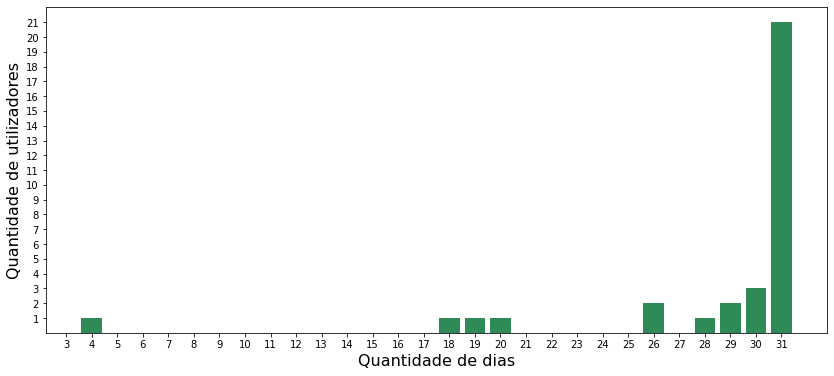

In [65]:
fig, ax = plt.subplots(figsize=(14, 6))

plt.xticks(list(range(1, 32)))
plt.yticks(list(range(1, 22)))
plt.xlabel('Quantidade de dias', fontsize=16)
plt.ylabel('Quantidade de utilizadores', fontsize=16)

plt.bar(valores_x, valores_y, color='seagreen')
plt.show()

### Conclusão do gráfico:

Podemos perceber que a maioria dos indivíduos utilizaram o dispostivo durante todos os dias do período considerado. Uma forma de maximizar os dias de rastreamento, para aqueles que não utilizaram todos os dias,  seria o envio de notificações diárias para os usuários do dispositivo.

Após, os dados serão divididos em 4 categorias, separados por tempo de rastreamento, sendo:
    
* Baixo rastreamento: 0 a 12 horas
* Médio rastreamento: 12 a 18 horas
* Alto rastreamento: 18 a 24 horas
* Total rastreamento: 24 horas  

Visualizaremos um gráfico de pizza, contendo a porcentagem de cada uma dessas categorias, para o conjunto de dados. Vale ressaltar que essa porcentagem não representa a quantidade de indivíduos, mas sim a quantidade de dias que cada indivíduo utilizou o dispositivo de acordo com as categorias acima.

In [66]:
categorias = ['total', 'alto', 'médio', 'baixo']

contador_baixo = 0
contador_medio = 0
contador_alto = 0
contador_total = 0

for dado in dataframe['trackingHours']:
    if dado < 12:
        categoria = 'baixa'
        contador_baixo += 1
    elif dado < 18:
        categoria = 'média'
        contador_medio += 1
    elif dado < 24:
        categoria = 'alta'
        contador_alto += 1
    else:
        categoria = 'total'
        contador_total += 1
        
valores = [contador_total, contador_alto, contador_medio, contador_baixo]    

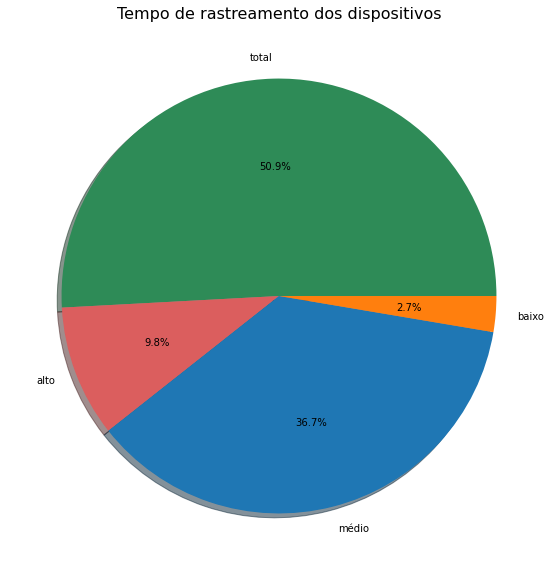

In [67]:
fig, ax = plt.subplots(figsize=(12, 10))

cores = ['seagreen', '#db5e5e', 'tab:blue', 'tab:orange']

ax.pie(valores, labels=categorias, autopct='%.1f%%', shadow=True, colors=cores)
ax.set_title('Tempo de rastreamento dos dispositivos', fontsize=16)

plt.show()

### Conclusão do gráfico:

Aqui vemos que, em cerca de 40% dos dias rastreados, os dispostivos foram utilizados menos de 18 horas. Podem ser realizadas ações de incentivo à utilização dos dispositivos durante todo o dia, como por exemplo, o envio de notificações diárias, como já citado anteriormente.

## Trabalhando com o conjunto de dados heartrate_seconds

Como demonstrado anteriormente, esse conjunto possui menos indivíduos (14) que o anterior.
Inicialmente, o conjunto de dados será carregado e depois, a coluna de data será transformada para o tipo correto.

In [2]:
dataframe = pd.read_csv(r'C:\Users\luisf\Desktop\database\final\heartrate_seconds_merged.csv')
dataframe['Time'] = pd.to_datetime(dataframe['Time'])

dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2483658 entries, 0 to 2483657
Data columns (total 3 columns):
 #   Column  Dtype         
---  ------  -----         
 0   Id      int64         
 1   Time    datetime64[ns]
 2   Value   int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 56.8 MB


Após isso, será coletada a informação de hora da coluna de data e inserido uma nova coluna com essa informação.

In [3]:
dataframe["hour"] = dataframe["Time"].dt.hour
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2483658 entries, 0 to 2483657
Data columns (total 4 columns):
 #   Column  Dtype         
---  ------  -----         
 0   Id      int64         
 1   Time    datetime64[ns]
 2   Value   int64         
 3   hour    int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 75.8 MB


In [4]:
media_bpmHora = dataframe.groupby("hour")['Value'].mean()
media_bpmHora

hour
0     66.723642
1     65.642436
2     63.566506
3     61.143456
4     60.231779
5     63.178442
6     72.910595
7     75.196996
8     76.951884
9     80.703932
10    80.116789
11    79.147566
12    83.566121
13    81.041155
14    82.090328
15    79.366156
16    83.914978
17    84.810547
18    86.128509
19    82.797117
20    78.967916
21    75.127449
22    72.228438
23    69.272406
Name: Value, dtype: float64

In [5]:
valores_bpm = media_bpmHora.tolist()
hora = list(range(0, 24))

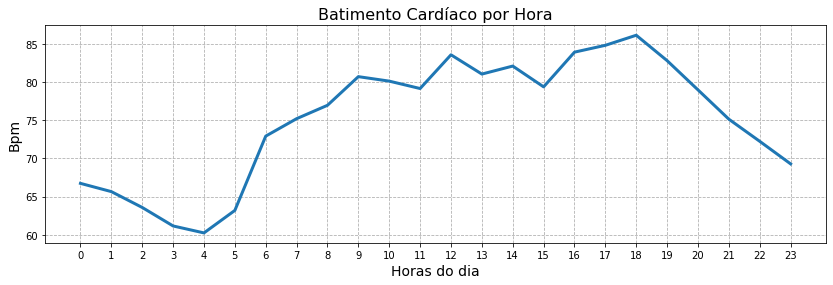

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))

plt.xticks(hora)
#plt.yticks(list(range(50, 100, 5)))
plt.xlabel('Horas do dia', fontsize=14)
plt.ylabel('Bpm', fontsize=14)
plt.title("Batimento Cardíaco por Hora", fontsize=16)
plt.grid(linestyle='--')

plt.plot(hora, valores_bpm, color='tab:blue', lw=3)
plt.show()

### Conclusão do gráfico:

Temos uma tendência esperada para o batimento cardíaco, por hora do dia, sendo a média mínima atingida entre 3 e 5 horas (durante o sono) e a máxima entre 17 e 19 horas. Como sugestão, deve-se entender o motivo da menor quantidade de indivíduos no conjunto de dados (relembrando que algumas possibilidades foram destacadas anteriormente neste estudo).  

## Trabalhando com o conjunto de dados hour_data

In [36]:
dataframe = pd.read_csv(r'C:\Users\luisf\Desktop\database\final\hour_data.csv')
dataframe['ActivityHour'] = pd.to_datetime(dataframe['ActivityHour'])

dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  22099 non-null  int64         
 1   ActivityHour        22099 non-null  datetime64[ns]
 2   Calories            22099 non-null  int64         
 3   TotalIntensity_x    22099 non-null  int64         
 4   AverageIntensity_x  22099 non-null  float64       
 5   TotalIntensity_y    22099 non-null  int64         
 6   AverageIntensity_y  22099 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4)
memory usage: 1.2 MB


Aparentemente as colunas TotalIntesity (x e y) e AverageIntensity (x e y) possuem valores idênticos. Foi realizado um teste para comparação dos valores dessas colunas e comprovado que elas apresentam mesmas informações. Portanto uma dupla de colunas será excluída do conjunto de dados.

In [45]:
x = dataframe['TotalIntensity_x'].tolist()
y = dataframe['TotalIntensity_y'].tolist()

for i in x:
    cont = 0
    if i == y[x.index(i)]:
        pass
    else:
        print(f'Valor x: {i} e valor y: {y[x.index(i)]}')
        cont += 1
if cont == 0:
    print('Colunas iguais')


Colunas iguais


In [46]:
x = dataframe['AverageIntensity_x'].tolist()
y = dataframe['AverageIntensity_y'].tolist()

for i in x:
    cont = 0
    if i == y[x.index(i)]:
        pass
    else:
        print(f'Valor x: {i} e valor y: {y[x.index(i)]}')
        cont += 1
if cont == 0:
    print('Colunas iguais')

Colunas iguais


In [47]:
dataframe = dataframe.drop(columns=["AverageIntensity_y", "TotalIntensity_y"])
dataframe.head()

,Id,ActivityHour,Calories,TotalIntensity_x,AverageIntensity_x
0,1503960366,2016-04-12 00:00:00,81,20,0.333333
1,1503960366,2016-04-12 01:00:00,61,8,0.133333
2,1503960366,2016-04-12 02:00:00,59,7,0.116667
3,1503960366,2016-04-12 03:00:00,47,0,0.000000
4,1503960366,2016-04-12 04:00:00,48,0,0.000000


Será criada uma coluna hora, assim como o conjunto de dados anterior e plotado um gráfico de linha com a média de calorias gastas. 

In [48]:
dataframe["hour"] = dataframe["ActivityHour"].dt.hour
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  22099 non-null  int64         
 1   ActivityHour        22099 non-null  datetime64[ns]
 2   Calories            22099 non-null  int64         
 3   TotalIntensity_x    22099 non-null  int64         
 4   AverageIntensity_x  22099 non-null  float64       
 5   hour                22099 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 1.0 MB


In [53]:
media_caloriasHora = dataframe.groupby("hour")['Calories'].mean()
valores_calorias = media_caloriasHora.tolist()
hora = list(range(0, 24))

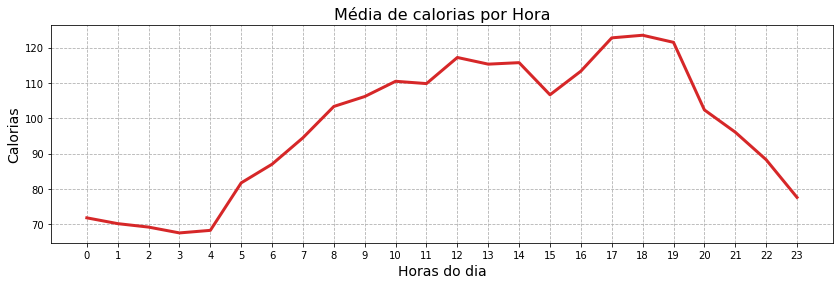

In [54]:
fig, ax = plt.subplots(figsize=(14, 4))

plt.xticks(hora)
#plt.yticks(list(range(50, 100, 5)))
plt.xlabel('Horas do dia', fontsize=14)
plt.ylabel('Calorias', fontsize=14)
plt.title("Média de calorias por Hora", fontsize=16)
plt.grid(linestyle='--')

plt.plot(hora, valores_calorias, color='tab:red', lw=3)
plt.show()

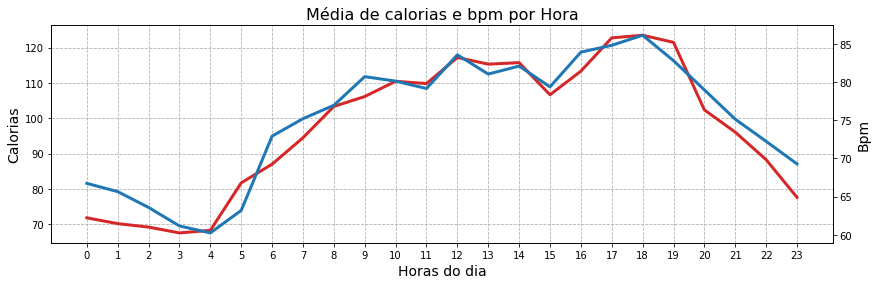

In [60]:
fig, left_ax = plt.subplots(figsize=(14, 4))

plt.title("Média de calorias e bpm por Hora", fontsize=16)
left_ax.grid(linestyle='--')

plt.xticks(hora)
left_ax.set_xlabel('Horas do dia', fontsize=14)
left_ax.set_ylabel('Calorias', fontsize=14)

left_ax.plot(hora, valores_calorias, color='tab:red', lw=3)

right_ax = left_ax.twinx()
right_ax.set_ylabel('Bpm', fontsize=14)
right_ax.plot(hora, valores_bpm, color='tab:blue', lw=3)

plt.show()

# EM DESENVOLVIMENTO

<AxesSubplot:>

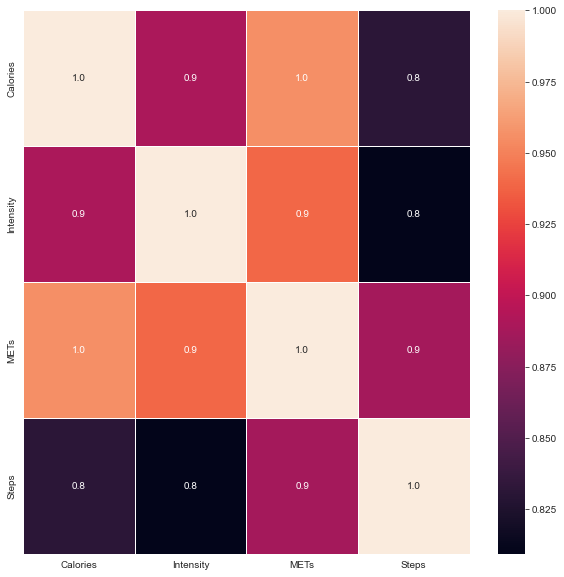

In [20]:
df = pd.read_csv(r'C:\Users\luisf\Desktop\database\final\minute_data.csv')
df = df.drop(columns=["Id"])

correlation = df.corr()

plt.figure(figsize=(10, 10))

plot = sns.heatmap(correlation, annot=True, fmt='.1f', linewidths=0.6)
plt.show()